**Install Libraries & Load Dataset**

In [ ]:
# Install required libraries
!pip install PyTDC

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 154.2/154.2 kB 3.3 MB/s eta 0:00:00
  Preparing metadata (setup.py) ... done
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 61.0/61.0 kB 2.4 MB/s eta 0:00:00
INFO: pip is looking at multiple versions of pytdc to determine which version is compatible with other requirements. This could take a while.
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 151.3/151.3 kB 6.4 MB/s eta 0:00:00
  Preparing metadata (setup.py) ... done
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 7.3/7.3 MB 40.0 MB/s eta 0:00:00
  Installing build dependencies ... done
  Getting requirements to build wheel ... done
  Preparing metadata (pyproject.toml) ... done
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 43.7/43.7 kB 2.6 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 151.2/151.2 kB 11.2 MB/s eta 0:00:00
  Preparing metadata (setup.py) ... done
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 151.2/151.2 kB 10.7 MB/s eta 0:00:00
  Preparing metadata (setup.py) ... d

In [ ]:
# Import dataset loader
from tdc.multi_pred import DTI

# Load BindingDB dataset (drug-target interactions)
data = DTI(name='BindingDB_Kd')

# Handle duplicate values (keep best binding)
data.harmonize_affinities(mode='max_affinity')

# Convert to dataframe
df = data.get_data()

# Convert binding value → classification
# If binding strength < 1000 → interaction (1), else no interaction (0)
threshold = 1000
df['interaction'] = df['Y'].apply(lambda x: 1 if x < threshold else 0)

# Keep only required columns
df = df[['Drug','Target','interaction']]

# Use smaller sample for faster training
df = df.sample(2000, random_state=42)

print(df.head())

ModuleNotFoundError: No module named 'tdc'

**Convert Drug (SMILES → Fingerprint)**

In [ ]:
# Install RDKit (for chemistry processing)
!pip install rdkit

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 36.7/36.7 MB 58.0 MB/s eta 0:00:00


In [ ]:
from rdkit import Chem
from rdkit.Chem import AllChem
import torch

# Function: Convert SMILES → numerical vector
def smiles_to_fp(smiles):

    # Convert SMILES to molecule
    mol = Chem.MolFromSmiles(smiles)
    # Skip invalid molecules
    if mol is None:
        return None

    # Morgan fingerprint (1024 features)
    fp = AllChem.GetMorganFingerprintAsBitVect(mol, 2, nBits=1024)
    return torch.tensor(list(fp), dtype=torch.float)

**Convert Protein (Sequence → Numbers)**

In [ ]:
import numpy as np

In [ ]:
# List of amino acids
amino_acids = list("ACDEFGHIKLMNPQRSTVWY")
# Map each amino acid → number
aa_dict = {aa:i for i,aa in enumerate(amino_acids)}

# Maximum protein length
max_len = 512

# Function: Encode protein sequence
def encode_protein(seq):

    # Convert letters → numbers
    arr = [aa_dict.get(a,0) for a in seq[:max_len]]

    # Pad sequence if shorter than max_len
    if len(arr) < max_len:
        arr += [0]*(max_len - len(arr))

    return torch.tensor(arr, dtype=torch.long)

**Attention Layer**

In [ ]:
import torch.nn as nn

In [ ]:
# This layer learns which parts of protein are important
class Attention(nn.Module):

    def __init__(self, dim):
        super().__init__()

        self.fc = nn.Linear(dim,1)

    def forward(self,x):
        # x is expected to be (sequence_length, batch_size, embedding_dim)
        # self.fc(x) will be (sequence_length, batch_size, 1)
        weights = torch.softmax(self.fc(x), dim=0) # Apply softmax over sequence length dimension
        # (weights * x) will be (sequence_length, batch_size, embedding_dim)
        output = (weights * x).sum(dim=0) # Sum over sequence length dimension
        # output will be (batch_size, embedding_dim)
        return output, weights

**Build Deep Learning Model**

In [ ]:
class Final_DTI_Model(nn.Module):

    def __init__(self):
        super().__init__()

        # Drug processing (fingerprint → features)
        self.drug_fc = nn.Linear(1024,256)

        # Protein embedding (like word embedding)
        self.embed = nn.Embedding(20,128)

        # Transformer encoder (learn sequence patterns)
        encoder_layer = nn.TransformerEncoderLayer(d_model=128, nhead=4)
        self.transformer = nn.TransformerEncoder(encoder_layer, num_layers=2)

        # Attention layer
        self.attn = Attention(128)

        # Final classification layers
        self.fc1 = nn.Linear(256+128,128)
        self.fc2 = nn.Linear(128,1)

        self.relu = nn.ReLU()
        self.sigmoid = nn.Sigmoid()

    def forward(self, drug, protein):

        # Drug feature extraction
        d = self.relu(self.drug_fc(drug))

        # Protein processing
        p = self.embed(protein).unsqueeze(1)
        p = self.transformer(p)

        # Apply attention
        p, attn_weights = self.attn(p)

        # Combine drug + protein features
        combined = torch.cat((d, p.squeeze()), dim=0)

        # Final prediction
        out = self.relu(self.fc1(combined))
        out = self.sigmoid(self.fc2(out))

        return out, attn_weights

**Prepare Dataset**

In [ ]:
dataset = []

for _,row in df.iterrows():

    # Convert drug and protein
    d = smiles_to_fp(row['Drug'])
    p = encode_protein(row['Target'])

    # Skip invalid drugs
    if d is not None:
        dataset.append((d,p,row['interaction']))

print("Dataset size:", len(dataset))

NameError: name 'df' is not defined

In [ ]:
from sklearn.model_selection import train_test_split

# Proper train-test split (VERY IMPORTANT)
train_data, test_data = train_test_split(dataset, test_size=0.2, random_state=42)

print("Train size:", len(train_data))
print("Test size:", len(test_data))

Train size: 1600
Test size: 400


**Train Model**

In [ ]:
model = Final_DTI_Model()

criterion = nn.BCELoss()
optimizer = torch.optim.Adam(model.parameters(), lr=0.001)

losses = [] # Initialize losses list

# Train for few epochs
for epoch in range(5):

    total_loss = 0

    for d,p,label in train_data:

        optimizer.zero_grad()

        pred,_ = model(d,p)


        loss = criterion(pred, torch.tensor([label], dtype=torch.float))

        loss.backward()
        optimizer.step()

        total_loss += loss.item()

    losses.append(total_loss) # Append total_loss for the epoch
    print("Epoch:", epoch+1, "Loss:", total_loss)

Epoch: 1 Loss: 909.8707336857915
Epoch: 2 Loss: 727.189562745858
Epoch: 3 Loss: 621.9287289483993
Epoch: 4 Loss: 558.8311709256968
Epoch: 5 Loss: 522.3532371030102


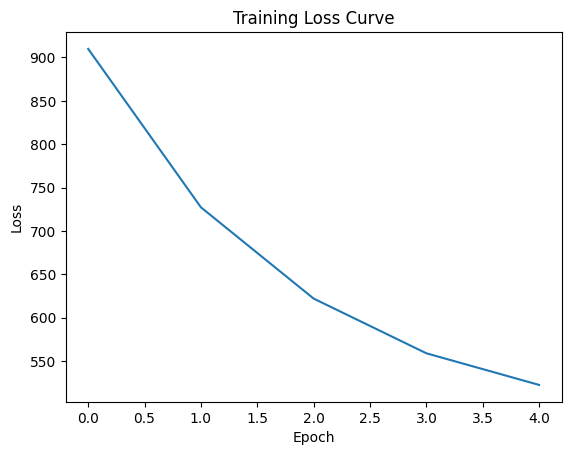

In [ ]:
import matplotlib.pyplot as plt

plt.plot(losses)
plt.title("Training Loss Curve")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.show()

**Model Evaluation**

In [ ]:
from sklearn.metrics import accuracy_score, f1_score, roc_auc_score, average_precision_score

y_true, y_pred, y_prob = [], [], []

# Test on unseen data
for d,p,label in dataset[500:800]:

    pred,_ = model(d,p)
    prob = pred.item()

    y_true.append(label)
    y_prob.append(prob)
    y_pred.append(1 if prob > 0.5 else 0)

# Print metrics
print("Accuracy:", accuracy_score(y_true,y_pred))
print("F1 Score:", f1_score(y_true,y_pred))
print("ROC-AUC:", roc_auc_score(y_true,y_prob))
print("PR-AUC:", average_precision_score(y_true,y_prob))

Accuracy: 0.8733333333333333
F1 Score: 0.7912087912087913
ROC-AUC: 0.8878286891679749
PR-AUC: 0.8313808023243747


**ROC Curve**

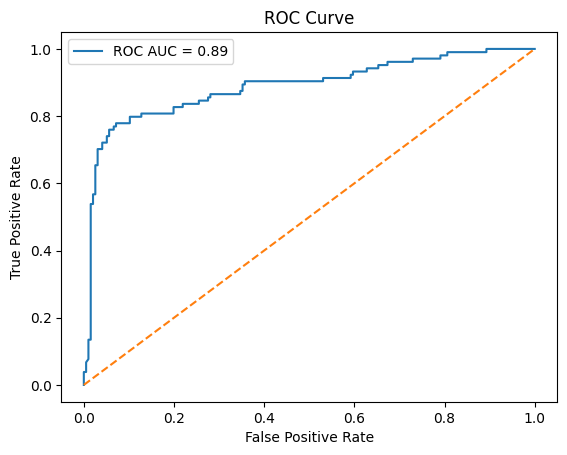

In [ ]:
!pip install matplotlib

import matplotlib.pyplot as plt
from sklearn.metrics import roc_curve, auc

fpr, tpr, _ = roc_curve(y_true, y_prob)
roc_auc = auc(fpr, tpr)

plt.figure()
plt.plot(fpr, tpr, label="ROC AUC = %0.2f" % roc_auc)
plt.plot([0,1],[0,1],'--')

plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve")
plt.legend()

plt.show()

**PR Curve**

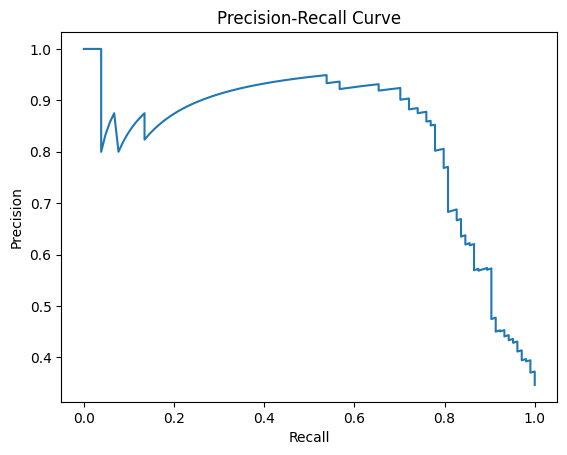

In [ ]:
from sklearn.metrics import precision_recall_curve

precision, recall, _ = precision_recall_curve(y_true, y_prob)

plt.figure()
plt.plot(recall, precision)

plt.xlabel("Recall")
plt.ylabel("Precision")
plt.title("Precision-Recall Curve")

plt.show()

**Prediction 1**


🔷 MODEL PREDICTION
Interaction Probability: 0.452

🔷 INTERPRETATION
👉 Moderate interaction possible.

This value (0.452) shows likelihood of interaction.

🔷 ADMET PROFILING REPORT

👉 Lipinski Rule Check:
Molecular Weight: 46.07
LogP: -0.0
H Donors: 1
H Acceptors: 1
✅ Drug-Like Molecule

👉 Blood-Brain Barrier (BBB):
🚫 Unlikely to cross BBB

👉 Toxicity (Heuristic):
✅ Lower toxicity risk

🔷 MOLECULE STRUCTURE



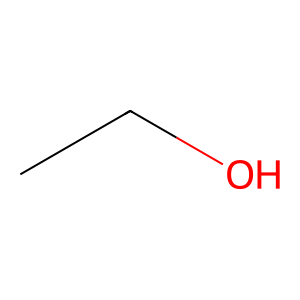


🔷 TOP SIMILAR DRUGS

🔹 Drug 1
SMILES: O=C(O)CC(O)(CC(=O)O)C(=O)O
Similarity Score: 0.105


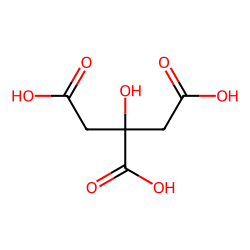

🔹 Drug 2
SMILES: CCCc1cc2c(cc1C(=O)c1ccc(C(=O)O)cc1)C(C)(C)CCC2(C)C
Similarity Score: 0.1


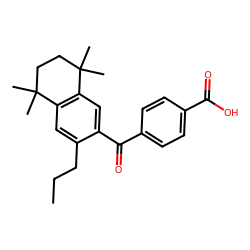

🔹 Drug 3
SMILES: CCN(CC)CCNC(=O)c1c(C)[nH]c(/C=C2\C(=O)Nc3ccc(F)cc32)c1C
Similarity Score: 0.089


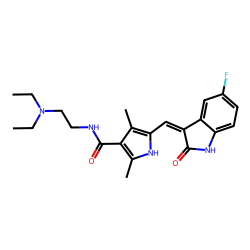

🔹 Drug 4
SMILES: CCN(CC)CCNC(=O)c1c(C)[nH]c(/C=C2\C(=O)Nc3ccc(F)cc32)c1C
Similarity Score: 0.089


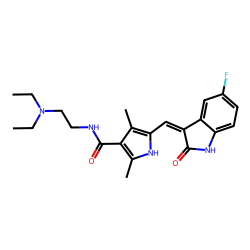

🔹 Drug 5
SMILES: C[C@]12CC[C@H]3[C@@H](CCC4=CC(=O)CC[C@@]43C)[C@@H]1CC[C@]2(O)C(=O)CO
Similarity Score: 0.085


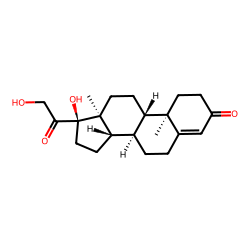


🔷 GRID VIEW (ALL DRUGS)



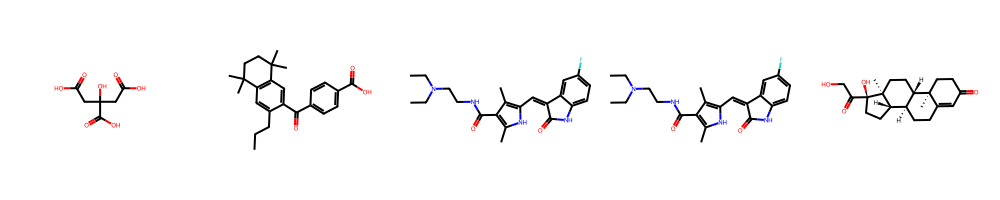

[('O=C(O)CC(O)(CC(=O)O)C(=O)O',
  0.10526315789473684,
  <rdkit.Chem.rdchem.Mol at 0x7d552d55e0a0>),
 ('CCCc1cc2c(cc1C(=O)c1ccc(C(=O)O)cc1)C(C)(C)CCC2(C)C',
  0.1,
  <rdkit.Chem.rdchem.Mol at 0x7d552d55eea0>),
 ('CCN(CC)CCNC(=O)c1c(C)[nH]c(/C=C2\\C(=O)Nc3ccc(F)cc32)c1C',
  0.08928571428571429,
  <rdkit.Chem.rdchem.Mol at 0x7d552d55cdd0>),
 ('CCN(CC)CCNC(=O)c1c(C)[nH]c(/C=C2\\C(=O)Nc3ccc(F)cc32)c1C',
  0.08928571428571429,
  <rdkit.Chem.rdchem.Mol at 0x7d552d55d0e0>),
 ('C[C@]12CC[C@H]3[C@@H](CCC4=CC(=O)CC[C@@]43C)[C@@H]1CC[C@]2(O)C(=O)CO',
  0.0851063829787234,
  <rdkit.Chem.rdchem.Mol at 0x7d552d55d2a0>)]

In [ ]:

# IMPORTS
from rdkit import Chem
from rdkit.Chem import AllChem, Descriptors, Draw
from rdkit.DataStructs import TanimotoSimilarity
from IPython.display import display
import torch

# ADMET FUNCTION

def admet_profile(smiles):
    mol = Chem.MolFromSmiles(smiles)
    if mol is None:
        print("Invalid molecule")
        return

    print("\n🔷 ADMET PROFILING REPORT")

    mw = Descriptors.MolWt(mol)
    logp = Descriptors.MolLogP(mol)
    h_donors = Descriptors.NumHDonors(mol)
    h_acceptors = Descriptors.NumHAcceptors(mol)

    print("\n👉 Lipinski Rule Check:")
    print("Molecular Weight:", round(mw,2))
    print("LogP:", round(logp,2))
    print("H Donors:", h_donors)
    print("H Acceptors:", h_acceptors)

    if mw < 500 and logp < 5 and h_donors <= 5 and h_acceptors <= 10:
        print("✅ Drug-Like Molecule")
    else:
        print("❌ May have poor drug-likeness")

    print("\n👉 Blood-Brain Barrier (BBB):")
    if logp > 2:
        print("🧠 Likely to cross BBB")
    else:
        print("🚫 Unlikely to cross BBB")

    print("\n👉 Toxicity (Heuristic):")
    if mw > 600:
        print("⚠️ Higher toxicity risk")
    else:
        print("✅ Lower toxicity risk")


# MOLECULE VISUALIZATION

def visualize_atoms(smiles):
    mol = Chem.MolFromSmiles(smiles)
    return Draw.MolToImage(mol)


# SIMILARITY SEARCH

def find_similar_drugs(query_smiles, df, top_n=5):

    query_mol = Chem.MolFromSmiles(query_smiles)
    query_fp = AllChem.GetMorganFingerprintAsBitVect(query_mol, 2, nBits=1024)

    similarities = []

    for sm in df['Drug'].head(100):

        mol = Chem.MolFromSmiles(sm)
        if mol is None:
            continue

        fp = AllChem.GetMorganFingerprintAsBitVect(mol, 2, nBits=1024)
        sim = TanimotoSimilarity(query_fp, fp)

        similarities.append((sm, sim, mol))

    similarities.sort(key=lambda x: x[1], reverse=True)
    top_results = similarities[:top_n]

    print("\n🔷 TOP SIMILAR DRUGS\n")

    mols = []

    for i, (sm, score, mol) in enumerate(top_results):

        print(f"🔹 Drug {i+1}")
        print("SMILES:", sm)
        print("Similarity Score:", round(score, 3))

        display(Draw.MolToImage(mol, size=(250,250)))
        mols.append(mol)

    print("\n🔷 GRID VIEW (ALL DRUGS)\n")

    grid_img = Draw.MolsToGridImage(mols, molsPerRow=top_n, subImgSize=(200,200))
    display(grid_img)

    return top_results


# FINAL PIPELINE FUNCTION

def full_drug_analysis(smiles, protein_seq, df):

    # Convert inputs
    d = smiles_to_fp(smiles)
    p = encode_protein(protein_seq)

    # Prediction
    pred, _ = model(d, p)
    prob = pred.item()

    print("\n🔷 MODEL PREDICTION")
    print("Interaction Probability:", round(prob, 4))

    # Interpretation
    print("\n🔷 INTERPRETATION")

    if prob > 0.8:
        print("👉 Very high probability that the drug strongly binds to the protein.")
    elif prob > 0.6:
        print("👉 High probability of binding between drug and protein.")
    elif prob > 0.4:
        print("👉 Moderate interaction possible.")
    else:
        print("👉 Low probability — drug is unlikely to bind effectively.")

    print(f"\nThis value ({round(prob,3)}) shows likelihood of interaction.")

    # ADMET
    admet_profile(smiles)

    # Visualization
    print("\n🔷 MOLECULE STRUCTURE\n")
    img = visualize_atoms(smiles)
    display(img)

    # Similar drugs
    similar = find_similar_drugs(smiles, df)

    return similar


# RUN EVERYTHING

full_drug_analysis(
    smiles="CCO",
    protein_seq="MAHVRGLQLPGCLALAALCSLVH",
    df=df
)

**Prediction 2**


🔷 MODEL PREDICTION
Interaction Probability: 0.8924

🔷 INTERPRETATION
👉 Very high probability that the drug strongly binds to the protein.

This value (0.892) shows likelihood of interaction.

🔷 ADMET PROFILING REPORT

👉 Lipinski Rule Check:
Molecular Weight: 180.16
LogP: 1.31
H Donors: 1
H Acceptors: 3
✅ Drug-Like Molecule

👉 Blood-Brain Barrier (BBB):
🚫 Unlikely to cross BBB

👉 Toxicity (Heuristic):
✅ Lower toxicity risk

🔷 MOLECULE STRUCTURE



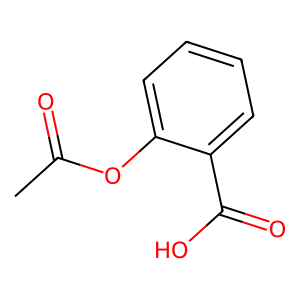


🔷 TOP SIMILAR DRUGS

🔹 Drug 1
SMILES: CCCc1cc2c(cc1C(=O)c1ccc(C(=O)O)cc1)C(C)(C)CCC2(C)C
Similarity Score: 0.216


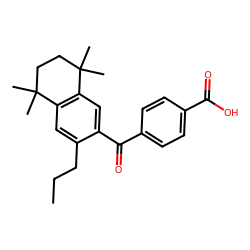

🔹 Drug 2
SMILES: CC(=C/C=C/C(C)=C/C(=O)O)/C=C1\CCC(C)c2ccccc21
Similarity Score: 0.193


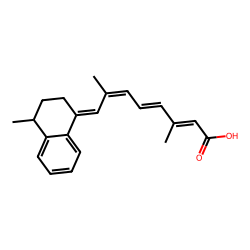

🔹 Drug 3
SMILES: CC(CCc1ccccc1)NCC(O)c1ccc(O)c(C(N)=O)c1
Similarity Score: 0.19


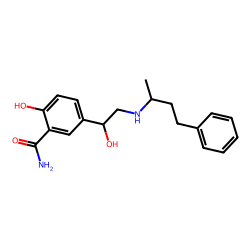

🔹 Drug 4
SMILES: COc1cccc2c1C[C@H]1C[C@@H](C(=O)N3CCc4c([nH]c5ccccc45)C3)CN(C)[C@@H]1C2
Similarity Score: 0.176


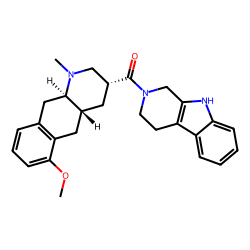

🔹 Drug 5
SMILES: O=C(c1ccc(/C=C/c2n[nH]c3ccccc23)cc1)N1CCNCC1
Similarity Score: 0.172


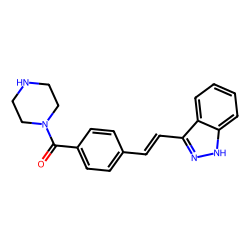


🔷 GRID VIEW (ALL DRUGS)



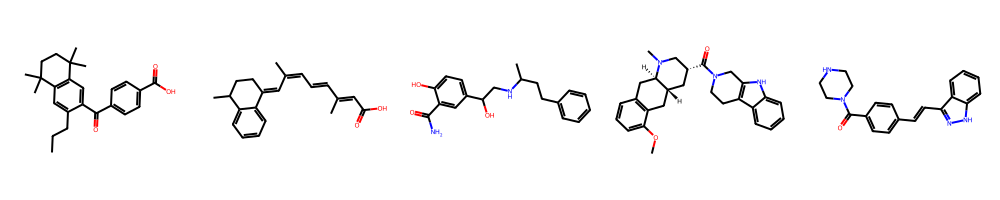

[('CCCc1cc2c(cc1C(=O)c1ccc(C(=O)O)cc1)C(C)(C)CCC2(C)C',
  0.21568627450980393,
  <rdkit.Chem.rdchem.Mol at 0x7d552d55f6f0>),
 ('CC(=C/C=C/C(C)=C/C(=O)O)/C=C1\\CCC(C)c2ccccc21',
  0.19298245614035087,
  <rdkit.Chem.rdchem.Mol at 0x7d552d55d770>),
 ('CC(CCc1ccccc1)NCC(O)c1ccc(O)c(C(N)=O)c1',
  0.1896551724137931,
  <rdkit.Chem.rdchem.Mol at 0x7d552d55f8b0>),
 ('COc1cccc2c1C[C@H]1C[C@@H](C(=O)N3CCc4c([nH]c5ccccc45)C3)CN(C)[C@@H]1C2',
  0.17567567567567569,
  <rdkit.Chem.rdchem.Mol at 0x7d552d55dc40>),
 ('O=C(c1ccc(/C=C/c2n[nH]c3ccccc23)cc1)N1CCNCC1',
  0.1724137931034483,
  <rdkit.Chem.rdchem.Mol at 0x7d552d55e180>)]

In [ ]:

# IMPORTS
from rdkit import Chem
from rdkit.Chem import AllChem, Descriptors, Draw
from rdkit.DataStructs import TanimotoSimilarity
from IPython.display import display
import torch

# ADMET FUNCTION

def admet_profile(smiles):
    mol = Chem.MolFromSmiles(smiles)
    if mol is None:
        print("Invalid molecule")
        return

    print("\n🔷 ADMET PROFILING REPORT")

    mw = Descriptors.MolWt(mol)
    logp = Descriptors.MolLogP(mol)
    h_donors = Descriptors.NumHDonors(mol)
    h_acceptors = Descriptors.NumHAcceptors(mol)

    print("\n👉 Lipinski Rule Check:")
    print("Molecular Weight:", round(mw,2))
    print("LogP:", round(logp,2))
    print("H Donors:", h_donors)
    print("H Acceptors:", h_acceptors)

    if mw < 500 and logp < 5 and h_donors <= 5 and h_acceptors <= 10:
        print("✅ Drug-Like Molecule")
    else:
        print("❌ May have poor drug-likeness")

    print("\n👉 Blood-Brain Barrier (BBB):")
    if logp > 2:
        print("🧠 Likely to cross BBB")
    else:
        print("🚫 Unlikely to cross BBB")

    print("\n👉 Toxicity (Heuristic):")
    if mw > 600:
        print("⚠️ Higher toxicity risk")
    else:
        print("✅ Lower toxicity risk")


# MOLECULE VISUALIZATION

def visualize_atoms(smiles):
    mol = Chem.MolFromSmiles(smiles)
    return Draw.MolToImage(mol)


# SIMILARITY SEARCH

def find_similar_drugs(query_smiles, df, top_n=5):

    query_mol = Chem.MolFromSmiles(query_smiles)
    query_fp = AllChem.GetMorganFingerprintAsBitVect(query_mol, 2, nBits=1024)

    similarities = []

    for sm in df['Drug'].head(100):

        mol = Chem.MolFromSmiles(sm)
        if mol is None:
            continue

        fp = AllChem.GetMorganFingerprintAsBitVect(mol, 2, nBits=1024)
        sim = TanimotoSimilarity(query_fp, fp)

        similarities.append((sm, sim, mol))

    similarities.sort(key=lambda x: x[1], reverse=True)
    top_results = similarities[:top_n]

    print("\n🔷 TOP SIMILAR DRUGS\n")

    mols = []

    for i, (sm, score, mol) in enumerate(top_results):

        print(f"🔹 Drug {i+1}")
        print("SMILES:", sm)
        print("Similarity Score:", round(score, 3))

        display(Draw.MolToImage(mol, size=(250,250)))
        mols.append(mol)

    print("\n🔷 GRID VIEW (ALL DRUGS)\n")

    grid_img = Draw.MolsToGridImage(mols, molsPerRow=top_n, subImgSize=(200,200))
    display(grid_img)

    return top_results


# FINAL PIPELINE FUNCTION

def full_drug_analysis(smiles, protein_seq, df):

    # Convert inputs
    d = smiles_to_fp(smiles)
    p = encode_protein(protein_seq)

    # Prediction
    pred, _ = model(d, p)
    prob = pred.item()

    print("\n🔷 MODEL PREDICTION")
    print("Interaction Probability:", round(prob, 4))

    # Interpretation
    print("\n🔷 INTERPRETATION")

    if prob > 0.8:
        print("👉 Very high probability that the drug strongly binds to the protein.")
    elif prob > 0.6:
        print("👉 High probability of binding between drug and protein.")
    elif prob > 0.4:
        print("👉 Moderate interaction possible.")
    else:
        print("👉 Low probability — drug is unlikely to bind effectively.")

    print(f"\nThis value ({round(prob,3)}) shows likelihood of interaction.")

    # ADMET
    admet_profile(smiles)

    # Visualization
    print("\n🔷 MOLECULE STRUCTURE\n")
    img = visualize_atoms(smiles)
    display(img)

    # Similar drugs
    similar = find_similar_drugs(smiles, df)

    return similar


# RUN EVERYTHING

full_drug_analysis(
    smiles="CC(=O)OC1=CC=CC=C1C(=O)O",
    protein_seq="MDSKGSSQKGSRLLLLLVVSNLLLCQGVVSTPVQL",
    df=df
)